In [1]:
import joblib
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
data = joblib.load("pkl_files/preprocessed_regression.pkl")

X_train = data["X_train"]
X_test = data["X_test"]
y_train = data["y_train"]
y_test = data["y_test"]


model = joblib.load("pkl_files/best_regression_model.pkl")

In [4]:
explainer = shap.LinearExplainer(model,X_train)
shap_values = explainer.shap_values(X_test)

In [5]:
sample_index = 0
sample = X_test.iloc[sample_index:sample_index + 1]

actual_value = y_test.iloc[sample_index]

predicted_value = model.predict(sample)[0]


print("Actual value:", actual_value)
print("Predicted value:", predicted_value)

Actual value: 1054000000
Predicted value: 932703234.6180857


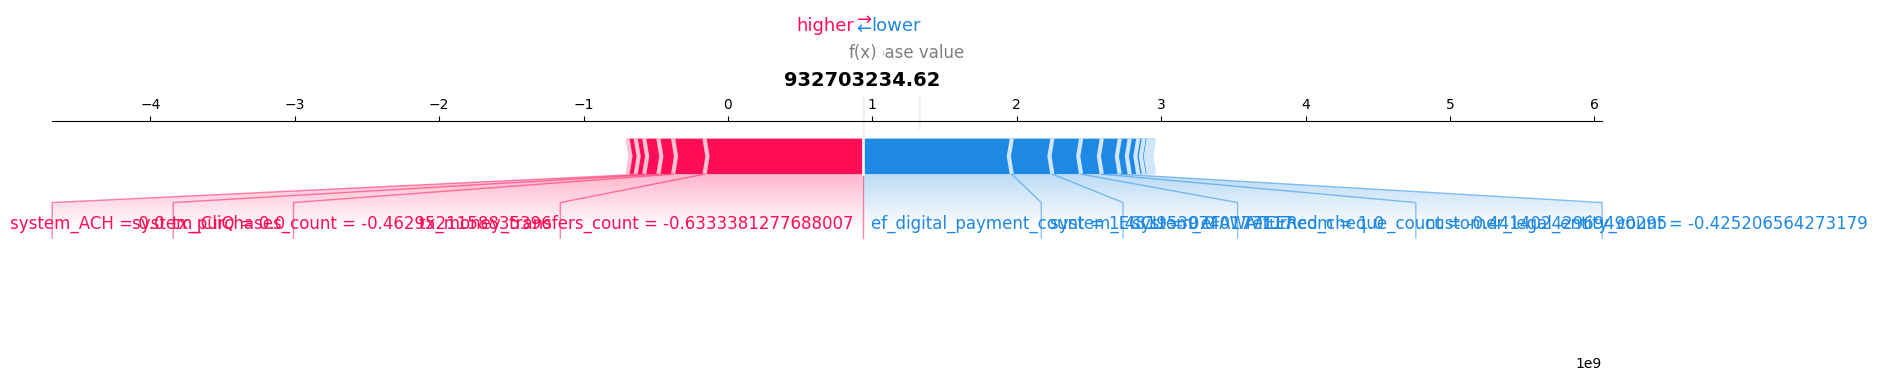

In [6]:
shap.force_plot(
    explainer.expected_value,
    shap_values[sample_index],
    sample.iloc[0],
    matplotlib=True
)

plt.show()

In [7]:
shap_results = pd.DataFrame({
    "Feature": X_test.columns,
    "Feature Value": sample.iloc[0].values,
    "SHAP Value": shap_values[sample_index]
})


shap_results

,Feature,Feature Value,SHAP Value
0,report_year,-1.081255,-3.346777e+07
1,report_month_number,-1.526067,-2.213291e+07
2,users_total,1.239662,-3.833586e+07
3,transactions_total,-0.003746,-5.902488e+07
4,customer_legal_entity_count,-0.425207,-1.244691e+08
5,wallet_individual_count,-0.522107,5.880549e+07
6,user_new_count,1.911729,-6.925148e+07
7,tx_purchases_count,-0.462952,2.177359e+08
8,tx_money_transfers_count,-0.633338,1.094672e+09
9,ef_digital_payment_count,1.481954,-1.033129e+09


In [8]:
cls_data = joblib.load("pkl_files/preprocessed_classification.pkl")


Xcls_train = cls_data["X_train"]
Xcls_test = cls_data["X_test"]
ycls_train = cls_data["y_train"]
ycls_test = cls_data["y_test"]


classification_model = joblib.load("pkl_files/best_classification_model.pkl")

In [9]:
classification_explainer = shap.TreeExplainer(classification_model)
classification_shap_values = (classification_explainer.shap_values(Xcls_test))

In [10]:
sample_index = 0

classification_sample = Xcls_test.iloc[sample_index:sample_index + 1]
actual_class = ycls_test.iloc[sample_index]
predicted_class = classification_model.predict(classification_sample)[0]

predicted_probabilities = (classification_model.predict_proba(classification_sample)[0])

class_index = np.where(classification_model.classes_ == predicted_class)[0][0]


print("Actual class:", actual_class)
print("Predicted class:", predicted_class)

print("Predicted class probability:",predicted_probabilities[class_index])

Actual class: 0
Predicted class: 0
Predicted class probability: 0.63


In [11]:
if isinstance(classification_shap_values,list):
    sample_class_shap_values = (classification_shap_values[class_index][sample_index])
    class_base_value = (classification_explainer.expected_value[class_index])

else:
    sample_class_shap_values = (classification_shap_values[sample_index,:,class_index])

    class_base_value = (classification_explainer.expected_value[class_index])

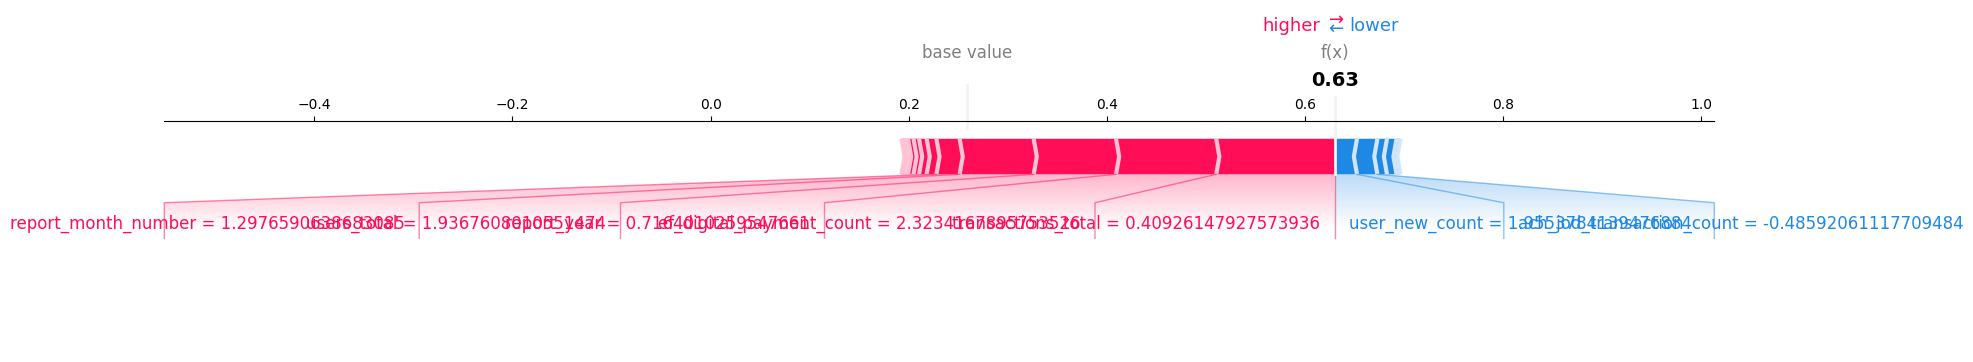

In [12]:
shap.force_plot(
    class_base_value,
    sample_class_shap_values,
    classification_sample.iloc[0],
    matplotlib=True
)


plt.show()

In [13]:
classification_shap_results = pd.DataFrame({
    "Feature": Xcls_test.columns,
    
    "Feature Value":
        classification_sample.iloc[0].values,
    
    "SHAP Value":
        sample_class_shap_values
})
classification_shap_results

,Feature,Feature Value,SHAP Value
0,report_year,0.716401,0.083121
1,report_month_number,1.297659,0.023426
2,users_total,1.936761,0.074749
3,transactions_total,0.409261,0.119575
4,customer_legal_entity_count,-0.455572,0.003360
5,wallet_individual_count,-0.494938,-0.009660
6,user_new_count,1.955378,-0.022478
7,tx_purchases_count,-0.496349,0.001932
8,tx_money_transfers_count,-0.647305,0.007632
9,ef_digital_payment_count,2.323417,0.101152


In [14]:
joblib.dump({"explainer":classification_explainer,"X_train":Xcls_train},"pkl_files/shap_classification_explainer.pkl")

['pkl_files/shap_classification_explainer.pkl']

In [15]:
joblib.dump({"explainer": explainer,"X_train": X_train},"pkl_files/shap_regression_explainer.pkl")

['pkl_files/shap_regression_explainer.pkl']